In [1]:
from scMM.file.data import CyESIData
data = CyESIData.load_from_filelist("/home/zby/scMM/data/choloroplasts",
                                ref_mz = 893.5425, cell_snr = 5.0, peak_snr = 1.5)

In [3]:
data.save("/home/zby/scMM/data/choloroplasts")

In [4]:
from scMM.plot.engine import PlotEngine
eg = PlotEngine.from_adata(data.to_anndata(), fig_path_dir="/home/zby/scMM/data/choloroplasts/fig")

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
eg.pca(n_components=50)
eg.umap(use_pca=True, n_neighbors=20, min_dist=0.7)

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


array([[-25.77926 ,  45.31079 ],
       [-26.038229,  48.78644 ],
       [-26.082035,  44.658966],
       ...,
       [-16.275923,  35.15761 ],
       [-16.897045,  33.701603],
       [-16.11145 ,  37.22908 ]], shape=(1396, 2), dtype=float32)

In [6]:
eg.cluster_cells(method="leiden", n_neighbors=20, resolution=0.2, key_added="leiden_cluster", s=20)

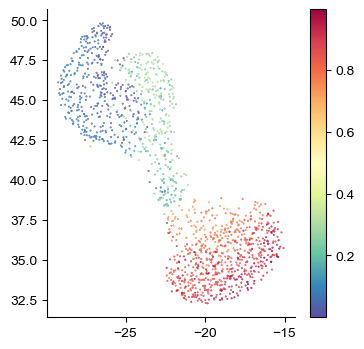

In [8]:
import matplotlib.pyplot as plt
X = eg.adata.obsm["X_umap"]
plt.scatter(X[:,0], X[:,1], c=data.peak_meta["time"], s=0.2)
plt.colorbar()
plt.show()

In [9]:
eg.compute_trajectory(step_size = 20, parameterization_key="time", plotting=True)

In [10]:
eg.plot_metabolite_trends(step_size=20, parameterization_key="time", plot_top_n=50, feature_name_key="mz")

In [11]:
eg.plot_trend_clusters()